In [1]:
import json
import os
from collections import UserDict
from collections.abc import Callable, Iterator
from functools import cached_property
from pathlib import Path

import ee
import ee.deserializer
import geemap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from dagster_components.partitions import zone_partitions

from nu_afolu.constants import LABEL_LIST


In [2]:
LABEL_MAP = dict(
    enumerate(
        [
            "croplands",
            "flooded",
            "forests_mangroves",
            "forests_primary",
            "forests_secondary",
            "grasslands",
            "other",
            "pastures",
            "settlements",
            "shrublands",
            "wetlands",
        ],
        start=1,
    )
)


SETTLEMENT_IDX = LABEL_LIST.index("settlements") + 1

In [3]:
ee.Initialize()

In [4]:
out_path = Path(os.environ["OUT_PATH"])

In [5]:
col_chen = ee.ImageCollection(
    "projects/sat-io/open-datasets/FUTURE-URBAN-LAND/CHEN_2020_2100"
)

In [6]:
def reduce_ssp_col(
    col: ee.ImageCollection, *, geometry: ee.Geometry, scale: float
) -> pd.DataFrame:
    reduced: ee.FeatureCollection = col.map(
        lambda img: ee.Feature(
            geometry,
            img.eq(ee.Number(2))
            .multiply(ee.Image.pixelArea())
            .reduceRegion(ee.Reducer.sum(), geometry=geometry, scale=scale),
        )
    )

    collected: dict[str, list[float]] = {}
    for suffix in range(1, 6):
        property_name = f"SSP{suffix}"
        arr = reduced.aggregate_array(property_name).getInfo()
        if not isinstance(arr, list):
            err = f"Expected list for property {property_name}, got {type(arr)}"
            raise TypeError(err)
        collected[property_name] = arr

    return pd.DataFrame(collected, index=list(range(2020, 2101, 10)))

In [7]:
class Zone:
    def __init__(
        self,
        bbox: ee.Geometry,
        area_raster: ee.Image,
        transition_raster: ee.Image,
        area_df: pd.DataFrame,
    ) -> None:
        self._bbox: ee.Geometry = bbox
        self.area_raster: ee.Image = area_raster
        self.transition_raster: ee.Image = transition_raster
        self.area_df: pd.DataFrame = area_df
        self._fields_to_invalidate: list[str] = ["ssp_rasters", "area_chen"]

    @property
    def bbox(self) -> ee.Geometry:
        return self._bbox

    @bbox.setter
    def bbox(self, value: ee.Geometry) -> None:
        self._bbox = value
        for field in self._fields_to_invalidate:
            if field in self.__dict__:
                del self.__dict__[field]

    @bbox.deleter
    def bbox(self) -> None:
        del self._bbox
        for field in self._fields_to_invalidate:
            if field in self.__dict__:
                del self.__dict__[field]

    @cached_property
    def ssp_images(self) -> dict[str, ee.Image]:
        ssp_images: dict[str, ee.Image] = {}
        for suffix in range(1, 6):
            name = f"SSP{suffix}"
            ssp_images[name] = (
                col_chen.select(name)
                .toBands()
                .rename([str(year) for year in range(2020, 2101, 10)])
                .eq(ee.Number(2))
                .clip(self.bbox)
                .selfMask()
            )
        return ssp_images

    @cached_property
    def area_chen(self) -> pd.DataFrame:
        return reduce_ssp_col(col_chen, geometry=self.bbox, scale=1000)

    @cached_property
    def settlement_mask(self) -> ee.Image:
        return self.area_raster.eq(ee.Number(SETTLEMENT_IDX))

    def resample_settlement_mask(self, ssp: str) -> ee.Image:
        return self.settlement_mask.reduceResolution(
            reducer=ee.Reducer.mean(), maxPixels=2048
        ).reproject(self.ssp_images[ssp].projection())

In [8]:
test = {"a": 1}
test.items()

dict_items([('a', 1)])

In [9]:
class ObservableDict(UserDict):
    def __init__(self, on_change: Callable, *args, **kwargs) -> None:
        self._on_change = on_change
        super().__init__(*args, **kwargs)

    def __setitem__(self, key: str, item: Zone) -> None:
        super().__setitem__(key, item)
        self._on_change()

    def __delitem__(self, key: str) -> None:
        super().__delitem__(key)
        self._on_change()


class GeoManager:
    def __init__(self) -> None:
        self._zones: ObservableDict = ObservableDict(self._invalidate)
        self._area_df: pd.DataFrame | None = None
        self._area_arr: xr.DataArray | None = None

    def _invalidate(self) -> None:
        self._area_df = None
        self._area_arr = None

    def __getitem__(self, key: str) -> Zone:
        return self._zones[key]

    def __setitem__(self, key: str, value: Zone) -> None:
        self._zones[key] = value

    def __delitem__(self, key: str) -> None:
        del self._zones[key]

    def __iter__(self) -> Iterator[tuple[str, Zone]]:
        return iter(self._zones.items())

    @property
    def zones(self) -> ObservableDict[str, Zone]:
        return self._zones

    @property
    def area_df(self) -> pd.DataFrame:
        if self._area_df is None:
            self._area_df = (
                pd.concat(
                    [zone.area_df.assign(zone=key) for key, zone in self._zones.items()]
                )
                .reset_index(names="year")
                .assign(year=lambda df: df["year"].astype(int))
                .set_index(["zone", "year"])
            )
        return self._area_df

    @property
    def area_arr(self) -> xr.DataArray:
        if self._area_arr is None:
            out = self.area_df.rename_axis(columns="category").stack().to_xarray()
            out.name = "area"
            if not isinstance(out, xr.DataArray):
                err = (
                    f"Expected area_arr to be an xarray.DataArray, but got {type(out)}"
                )
                raise TypeError(err)
            self._area_arr = out
        return self._area_arr

In [10]:
manager = GeoManager()

for zone in zone_partitions.get_partition_keys():
    try:
        with (out_path / "bbox" / "ee" / f"{zone}.json").open() as f:
            bbox: ee.Geometry = ee.deserializer.decode(json.load(f))

        with (out_path / "area_raster" / f"{zone}.json").open() as f:
            area_raster: ee.Image = ee.deserializer.decode(json.load(f)).clip(bbox)
            area_raster = area_raster.updateMask(area_raster.neq(ee.Number(0)))

        with (out_path / "transition_raster" / f"{zone}.json").open() as f:
            transition_raster: ee.Image = ee.deserializer.decode(json.load(f)).clip(
                bbox
            )
            transition_raster = transition_raster.updateMask(
                transition_raster.neq(ee.Number(0))
            )

        area_df = pd.read_parquet(out_path / "area_table" / f"{zone}.parquet")
    except FileNotFoundError:
        continue

    manager[zone] = Zone(
        bbox=bbox,
        area_raster=area_raster,
        transition_raster=transition_raster,
        area_df=area_df,
    )

In [11]:
manager.area_df

label            croplands       flooded  forests_secondary    grasslands  \
zone    year                                                                
01.1.01 2000  3.439613e+08  2.820432e+06       4.338473e+07  2.187204e+08   
        2001  3.917553e+08  2.985861e+06       4.348602e+07  1.962504e+08   
        2002  4.091223e+08  3.190284e+06       4.605149e+07  1.764081e+08   
        2003  4.134450e+08  3.300330e+06       4.798114e+07  1.772569e+08   
        2004  3.799716e+08  3.281370e+06       5.116564e+07  2.098606e+08   
...                    ...           ...                ...           ...   
32.1.01 2017  3.186790e+08  2.129854e+06       3.568992e+07  2.065529e+08   
        2018  3.152456e+08  1.906529e+06       3.778729e+07  2.069132e+08   
        2019  3.131799e+08  1.706253e+06       3.828394e+07  2.068227e+08   
        2020  3.228578e+08  6.079527e+05       3.873513e+07  2.026467e+08   
        2021  3.243805e+08  1.038841e+06       3.873045e+07  2.019559e+08   

label                other      pastures   settlements    shrublands  \
zone    year                                                           
01.1.01 2000  5.784025e+05  1.449178e+08  1.185805e+08  2.081465e+08   
        2001  6.756836e+05  1.298504e+08  1.246981e+08  1.913236e+08   
        2002  4.495991e+05  1.167227e+08  1.288741e+08  2.001877e+08   
        2003  7.479721e+05  1.173873e+08  1.355767e+08  1.854172e+08   
        2004  1.338887e+06  1.389585e+08  1.386973e+08  1.579806e+08   
...                    ...           ...           ...           ...   
32.1.01 2017  3.196644e+05  1.380442e+08  6.248090e+07  4.787549e+07   
        2018  4.055684e+05  1.381905e+08  6.115615e+07  4.998519e+07   
        2019  4.435579e+05  1.380841e+08  6.442683e+07  4.859937e+07   
        2020  4.452134e+05  1.352461e+08  6.580082e+07  4.442987e+07   
        2021  4.852546e+05  1.346953e+08  6.449441e+07  4.533298e+07   

label             wetlands  forests_primary  forests_mangroves  
zone    year                                                    
01.1.01 2000  2.230757e+06              NaN                NaN  
        2001  2.315506e+06              NaN                NaN  
        2002  2.334638e+06              NaN                NaN  
        2003  2.228365e+06              NaN                NaN  
        2004  2.086333e+06              NaN                NaN  
...                    ...              ...                ...  
32.1.01 2017  2.353389e+06              NaN                NaN  
        2018  2.535410e+06              NaN                NaN  
        2019  2.578704e+06              NaN                NaN  
        2020  3.355703e+06              NaN                NaN  
        2021  3.011669e+06              NaN                NaN  

[1320 rows x 11 columns]

In [12]:
y = manager.area_df.xs(2020, level="year")["settlements"].div(1e6)
yhat = (
    pd.concat([zone.area_chen.loc[2020].rename(name) for name, zone in manager], axis=1)
    .transpose()
    .div(1e6)
)

df_diffs = yhat.sub(y, axis=0)

mae = df_diffs.abs().mean()
rmse = np.sqrt((df_diffs**2).mean())
ape = df_diffs.abs().div(y, axis=0)

df_summary = pd.DataFrame(
    {
        "MAE (km2)": mae.round(2),
        "RMSE (km2)": rmse.round(2),
        "APE mean": ape.mean().mul(100).round().astype(int).astype(str) + "%",
        "APE median": ape.median().mul(100).round().astype(int).astype(str) + "%",
    }
)
df_summary

,MAE (km2),RMSE (km2),APE mean,APE median
SSP1,48.07,74.88,1194%,28%
SSP2,48.20,74.27,1149%,27%
SSP3,49.31,74.32,1147%,29%
SSP4,47.71,73.84,1190%,27%
SSP5,47.92,74.82,1162%,27%


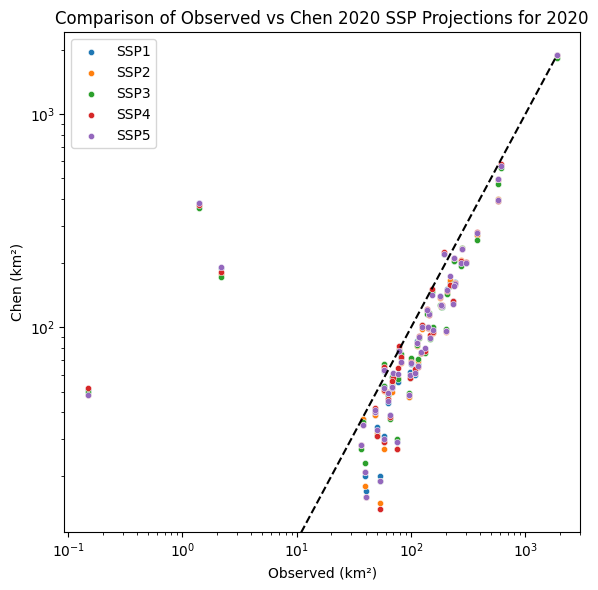

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xscale("log")
ax.set_yscale("log")

for suffix in range(1, 6):
    sns.scatterplot(x=y, y=yhat[f"SSP{suffix}"], ax=ax, label=f"SSP{suffix}", s=20)
ax.plot([0, y.max()], [0, y.max()], "k--")

ax.set_title("Comparison of Observed vs Chen 2020 SSP Projections for 2020")
ax.set_xlabel("Observed (km²)")
ax.set_ylabel("Chen (km²)")
fig.tight_layout()

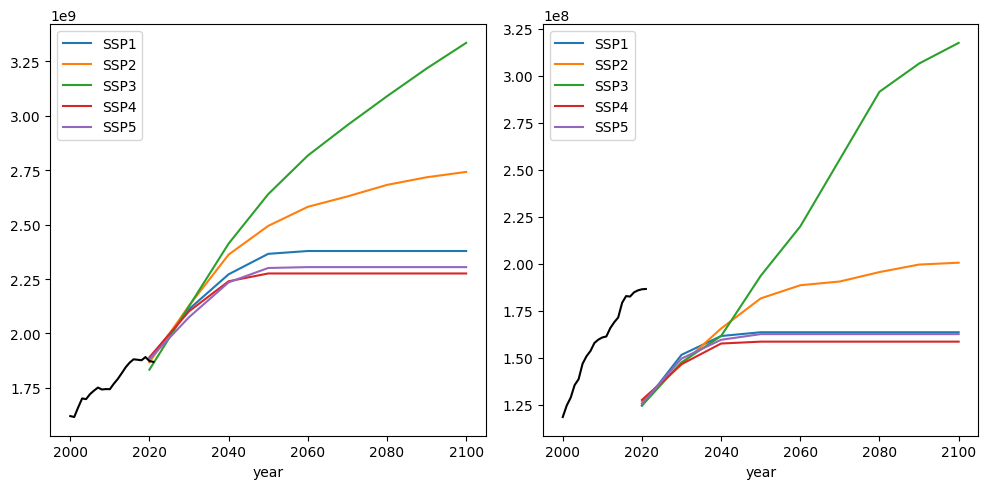

In [14]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(10, 5))

for ax, code in zip((axl, axr), ["09.1.01", "01.1.01"], strict=True):
    manager[code].area_chen.plot(ax=ax)
    manager[code].area_df["settlements"].plot(ax=ax, label="Observed", c="k")
fig.tight_layout()

In [15]:
areas_by_class: list[pd.Series] = []

for name, zone in manager:
    mask = zone.ssp_images["SSP1"].select("2020")
    masked = zone.area_raster.select("2020").updateMask(mask)

    result = (
        ee.Image.pixelArea()
        .addBands(masked)
        .reduceRegion(
            reducer=ee.Reducer.sum().group(groupField=1, groupName="label"),
            geometry=zone.bbox,
            scale=30,
            maxPixels=int(1e10),
        )
        .getInfo()
    )


    areas_by_class.append(pd.Series({LABEL_MAP[int(g["label"])]: g["sum"] for g in result["groups"]}).rename(name))

df_areas_by_class = pd.concat(areas_by_class, axis=1).transpose()

<Axes: >

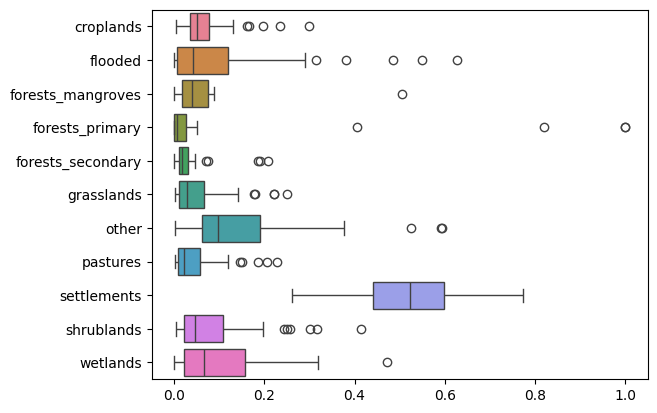

In [26]:
sns.boxplot(df_areas_by_class.div(manager.area_df.xs(2020, level="year")), orient="h")

In [30]:
zone = manager["01.1.01"]

m = geemap.Map()
m.addLayer(zone.ssp_images["SSP1"], {"min": 0, "max": 1, "bands": ["2020"], "palette": ["red"]})
m.addLayer(zone.area_raster.eq(ee.Number(SETTLEMENT_IDX)).selfMask(), {"min": 0, "max": 1, "bands": ["2020"], "palette": ["green"]})
m.centerObject(zone.bbox)
m

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [36]:
zone = manager["01.1.01"]

m = geemap.Map()
m.addLayer(zone.ssp_images["SSP1"], {"min": 0, "max": 1, "bands": ["2020"], "palette": ["red"]})
m.addLayer(
    zone.resample_settlement_mask("SSP1").select("2020").gte(0.6).selfMask(),
    {"min": 0, "max": 1, "palette": "green"},
    "Resampled",
)
m.centerObject(zone.bbox, 11)
m

Map(center=[21.887447862322954, -102.29837192303182], controls=(WidgetControl(options=['position', 'transparen…

In [59]:
m = geemap.Map()
m.addLayer(
    ssp_images["SSP1"],
    {"min": 0, "max": 1, "bands": ["2100"], "palette": "red"},
    "SSP1",
)
m.addLayer(
    settlement_mask.select("2020").selfMask(),
    {"min": 0, "max": 1, "palette": "blue"},
    "Settlements",
)
m.addLayer(
    settlement_mask_resampled.select("2020").gt(0.1).selfMask(),
    {"min": 0, "max": 1, "palette": "green"},
    "Resampled",
)

m.addLayer(bbox)
m.addLayer(bbox_buffered)

m.centerObject(bbox, 11)
m

Map(center=[21.887447862322954, -102.29837192303182], controls=(WidgetControl(options=['position', 'transparen…

In [66]:
source_settlement_area = df_area.loc[2020, "settlements"]
for ssp in df_chen.columns:
    ssp_area = df_chen.loc[2020, ssp]
    print(f"{ssp}: {int(ssp_area):,} m^2 ({ssp_area / source_settlement_area:.2%})")

SSP1: 124,666,666 m^2 (66.84%)
SSP2: 126,666,666 m^2 (67.91%)
SSP3: 124,666,666 m^2 (66.84%)
SSP4: 127,666,666 m^2 (68.44%)
SSP5: 125,666,666 m^2 (67.37%)
